# OV-circuit analysis: what token map do pairing & aggregation heads implement?

For each head, the **read** (W_V) and **write** (W_O) compose into one low-rank map
`OV = W_V @ W_O` (d_model -> d_model). Projecting through the token embedding/unembedding,
`W_E @ OV @ W_U`, gives a **token -> token** map: "input token at the read position ->
which output token gets boosted at the write position." This is the head's actual function,
both sides composed, read out in interpretable token space (the standard OV-circuit method).

- diagonal-dominant  -> head copies input identity (induction-like)
- structured off-diag -> head maps input tokens to *related* output tokens (transform-like)
- flat / no structure -> head writes ~constant regardless of input (positional/structural)

Pure weight analysis: no forward passes, runs instantly. `experiments/interplay/`.

In [1]:
import os, sys, pickle
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch

import experiments.pairing._common as C
from data.loaders import load_dataset
from utils.heads import select_scope
sns.set_context('notebook')

## Load model + head sets

In [2]:
DATASET = 'nonce+arithmetic'
HEAD_PCT = 10
SCOPE = 'pooled'
CUDA = '0'
ds_tag = DATASET.replace('+','_')

model = C.load_model(cuda_visible=CUDA)
with open(f'../../results/head_sets_{ds_tag}_pct{HEAD_PCT}.pkl','rb') as f: ms = pickle.load(f)
pairing     = select_scope(ms, SCOPE)['pairing']
aggregation = select_scope(ms, SCOPE)['aggregation']
print(f'{len(pairing)} pairing, {len(aggregation)} aggregation heads')

W_E = model.W_E.detach().float()
W_U = model.W_U.detach().float()
n_kv = model.cfg.n_key_value_heads or model.cfg.n_heads   # GQA: fewer KV heads
grp  = model.cfg.n_heads // n_kv

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
67 pairing, 67 aggregation heads


## OV-circuit in token space

In [3]:
@torch.no_grad()
def ov_circuit_tokenspace(L, h, vocab_ids):
    W_O = model.blocks[L].attn.W_O[h].detach().float()           # (d_head, d_model)
    Wv_full = model.blocks[L].attn.W_V
    kv_h = h // grp if Wv_full.shape[0] == n_kv else h           # map query head -> KV head (GQA)
    W_V = Wv_full[kv_h].detach().float()                         # (d_model, d_head)
    OV = W_V @ W_O                                               # (d_model, d_model)
    Esub = W_E[vocab_ids]; Usub = W_U[:, vocab_ids]
    return (Esub @ OV @ Usub).cpu().numpy()                      # (|V|, |V|)

def diag_dominance(M):
    ranks = [int(np.where(np.argsort(-M[i]) == i)[0][0]) for i in range(M.shape[0])]
    return float(np.mean(np.array(ranks) == 0)), float(np.mean(ranks))

# task-relevant single-token vocab: a-z + digits 0-9
chars = [chr(c) for c in range(ord('a'), ord('z')+1)] + [str(d) for d in range(10)]
vocab_ids, vocab_lab = [], []
for ch in chars:
    tid = model.to_tokens(ch, prepend_bos=False)[0]
    if tid.shape[0] == 1:
        vocab_ids.append(tid[0].item()); vocab_lab.append(ch)
vocab_ids = np.array(vocab_ids)
print(f'{len(vocab_ids)} single-token vocab items; chance frac_top1_diag={1/len(vocab_ids):.3f}, '
      f'chance mean_rank={(len(vocab_ids)-1)/2:.1f}')

36 single-token vocab items; chance frac_top1_diag=0.028, chance mean_rank=17.5


## Diagonal-dominance per head (copy-like?)

             frac_top1_diag  mean_self_rank
group                                      
aggregation           0.241          12.740
pairing               0.239          16.945
 head       group  frac_top1_diag  mean_self_rank
15.15 aggregation        1.000000        0.000000
13.18 aggregation        1.000000        0.000000
 13.9 aggregation        1.000000        0.000000
 12.6 aggregation        1.000000        0.000000
 13.9     pairing        1.000000        0.000000
 14.6     pairing        1.000000        0.000000
12.22 aggregation        0.972222        0.083333
12.23 aggregation        0.972222        0.055556
 14.7     pairing        0.972222        0.027778
 9.22     pairing        0.944444        0.055556


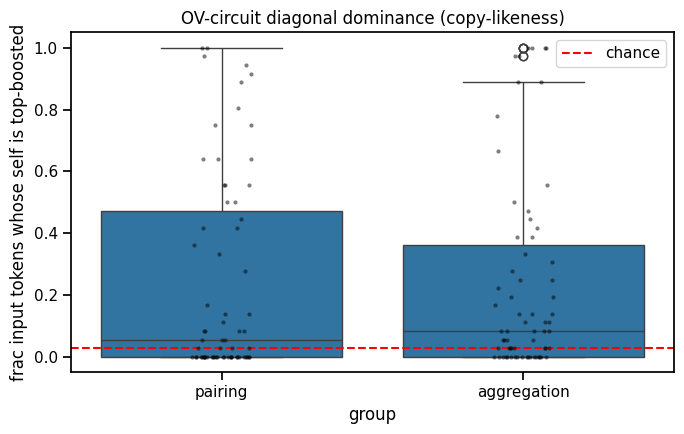

In [4]:
rows=[]
for grp_name, heads in [('pairing', pairing), ('aggregation', aggregation)]:
    for (L,h) in heads:
        M = ov_circuit_tokenspace(L, h, vocab_ids)
        fd, mr = diag_dominance(M)
        rows.append({'head':f'{L}.{h}','group':grp_name,'frac_top1_diag':fd,'mean_self_rank':mr})
D = pd.DataFrame(rows)
print(D.groupby('group')[['frac_top1_diag','mean_self_rank']].mean().round(3).to_string())
print(D.sort_values('frac_top1_diag', ascending=False).head(10).to_string(index=False))

fig,ax=plt.subplots(figsize=(7,4.5))
sns.boxplot(D, x='group', y='frac_top1_diag', ax=ax)
sns.stripplot(D, x='group', y='frac_top1_diag', color='k', size=3, alpha=.5, ax=ax)
ax.axhline(1/len(vocab_ids), ls='--', color='r', label='chance')
ax.set(title='OV-circuit diagonal dominance (copy-likeness)', ylabel='frac input tokens whose self is top-boosted')
ax.legend(); plt.tight_layout(); plt.show()

## Heatmap: most copy-like pairing head (and an aggregation head)

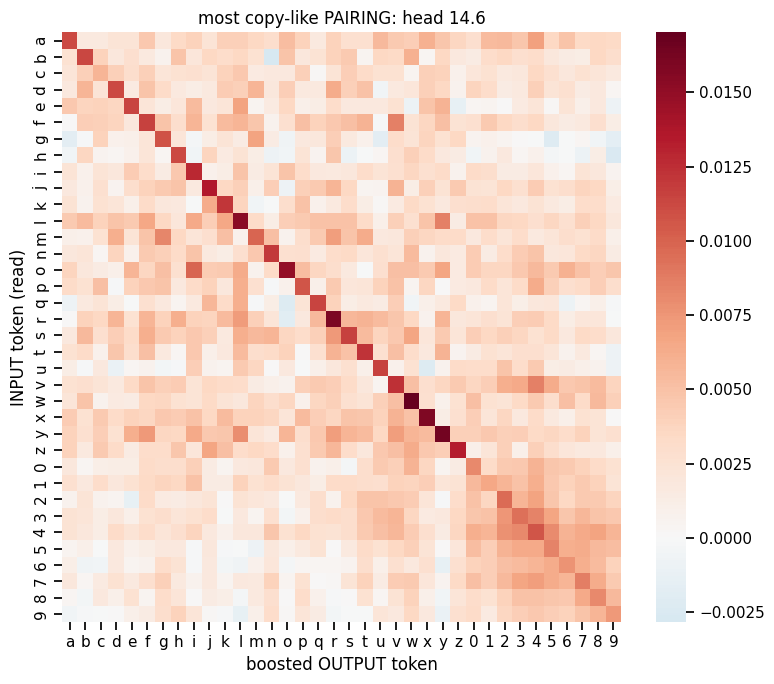

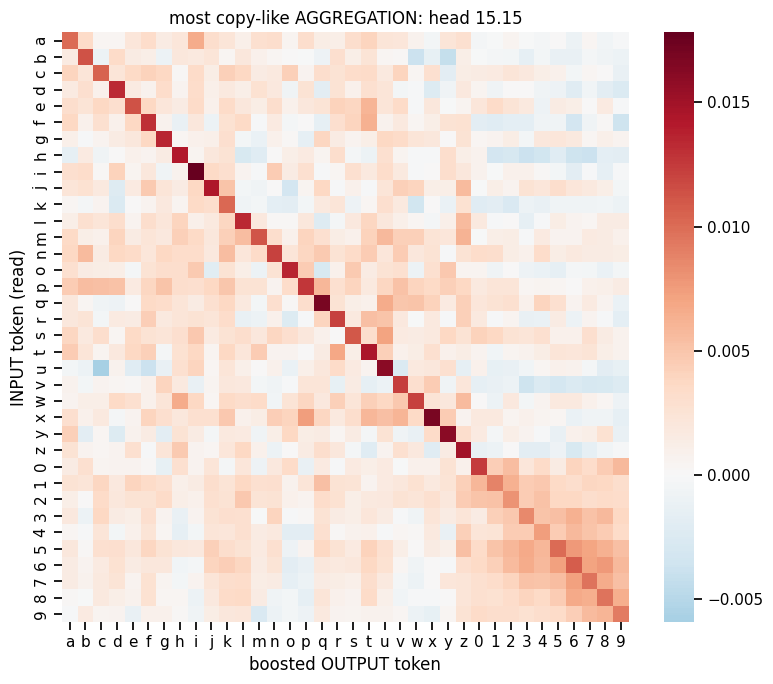

In [5]:
def show_head(headname, title):
    L,h = map(int, headname.split('.'))
    M = ov_circuit_tokenspace(L, h, vocab_ids)
    fig,ax=plt.subplots(figsize=(8,7))
    sns.heatmap(M, xticklabels=vocab_lab, yticklabels=vocab_lab, cmap='RdBu_r', center=0, ax=ax)
    ax.set(title=f'{title}: head {headname}', xlabel='boosted OUTPUT token', ylabel='INPUT token (read)')
    plt.tight_layout(); plt.show()

best_p = D[D.group=='pairing'].sort_values('frac_top1_diag', ascending=False).iloc[0]['head']
best_a = D[D.group=='aggregation'].sort_values('frac_top1_diag', ascending=False).iloc[0]['head']
show_head(best_p, 'most copy-like PAIRING')
show_head(best_a, 'most copy-like AGGREGATION')

## Read it
- **frac_top1_diag >> chance (red line)** -> heads copy input identity to the output
  (induction-like). Would mean the earlier "writes don't encode input identity" null was a
  projection artifact, and the OV circuit recovers the real function.
- **at chance, flat heatmap** -> heads implement no token-level map; consistent with the
  positional/structural story from both read and write sides.
- **structured off-diagonal in the heatmap** -> heads map input tokens to *related* output
  tokens (e.g. for reverse, look for anti-diagonal / character-shift structure) -> part of the
  transform lives in the attention OV circuit, not only the MLP.

Caveat: mid/late-layer heads read PROCESSED residual, not raw embeddings, so the raw-token
OV circuit is an approximation -- a diagonal result is strong positive evidence, but a flat
result doesn't fully rule out structure in the processed space.